    # Notebook de Correção e Interpolação Populacional

### Este script realiza a correção das estimativas populacionais do DATASUS utilizando os dados dos Censos 2010 e 2022 como pontos de referência.

Fluxo de processamento:
1. Carrega dados do DATASUS e Censos
2. Aplica correção baseada nos pontos de ancoragem do Censo
3. Gera visualizações para validação
4. Interpola os dados para frequência mensal
5. Salva o resultado final




---- Diagnóstico do arquivo: ../data/raw/populacao_datasus.csv ----
Tipos detectados:
Municipio    object
2010          int64
2011          int64
2012          int64
2013          int64
2014          int64
2015          int64
2016          int64
2017          int64
2018          int64
2019          int64
2020          int64
2021          int64
2022          int64
2023          int64
dtype: object

Amostra de dados:
                      Municipio   2010   2011   2012    2013    2014    2015  \
0  110001 ALTA FLORESTA D'OESTE  24422  24228  24069   25728   25652   25578   
1              110002 ARIQUEMES  90354  91570  92747  101269  102860  104401   
2                 110003 CABIXI   6309   6221   6132    6495    6424    6355   
3                 110004 CACOAL  78601  78959  79330   85863   86556   87226   
4             110005 CEREJEIRAS  17030  16939  16852   18041   18013   17986   

     2016    2017    2018    2019    2020    2021   2022   2023  
0   25506   25437   23167   22945

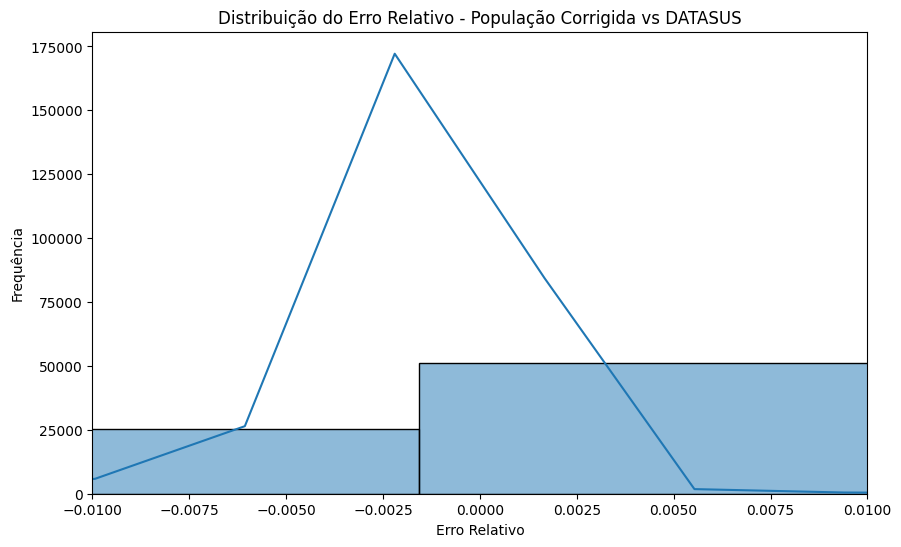

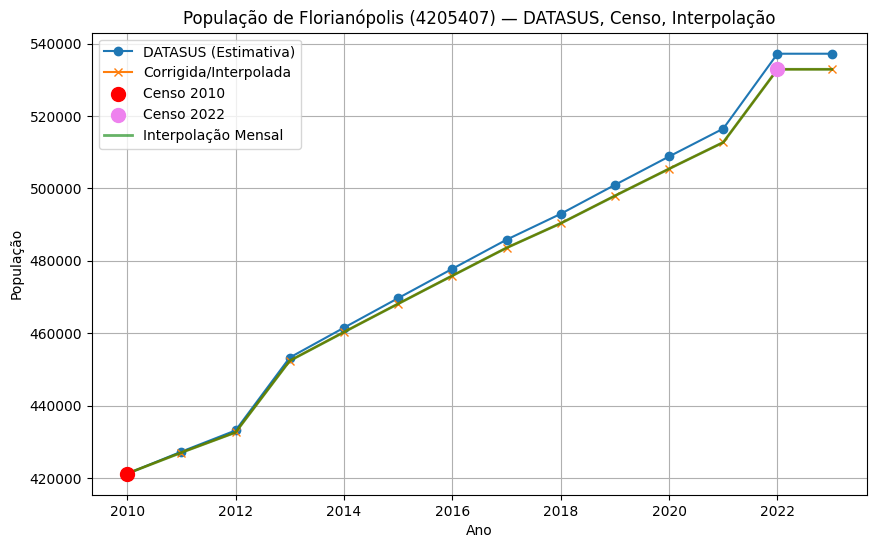

,data,pop_corrigida,municipio
0,2010-01-01,24392.000000,1100015
1,2010-02-01,24375.637172,1100015
2,2010-03-01,24359.274343,1100015
3,2010-04-01,24342.911515,1100015
4,2010-05-01,24326.548686,1100015


In [1]:
from src.load_data import load_datasus, load_censo_2010_2012, load_censo_2022, diagnostico_csv
from src.preprocess_pop import (
    aplicar_correcao,
    gerar_grafico_erro,
    interpolar_mensal,
    grafico_populacao_floripa
)

diagnostico_csv('../data/raw/populacao_datasus.csv', sep=';', encoding='utf-8')
diagnostico_csv('../data/raw/dados_censo_2010_a_2012.csv', sep=';', encoding='latin1')
diagnostico_csv('../data/raw/dados_censo_2022.csv', encoding='utf-8')
diagnostico_csv('../data/raw/dados_tse.csv', encoding='utf-8')

censo_2022 = load_censo_2022('../data/raw/dados_censo_2022.csv')
datasus = load_datasus('../data/raw/populacao_datasus.csv', censo_2022)
censo_2010_2012 = load_censo_2010_2012('../data/raw/dados_censo_2010_a_2012.csv', censo_2022)
censo_2010 = censo_2010_2012.copy()

# 🔧 Aplicar correção
pop_corrigida = aplicar_correcao(datasus, censo_2010, censo_2022)

df = pop_corrigida[pop_corrigida['municipio'] == '1100023']

print(datasus['municipio'].unique()[:5])
print(censo_2010['municipio'].unique()[:5])
print(censo_2022['municipio'].unique()[:5])

gerar_grafico_erro(
    pop_corrigida, path_save='../figures/graficos_populacao/erro_relativo.png'
)

pop_mensal = interpolar_mensal(pop_corrigida)

grafico_populacao_floripa(pop_corrigida, df_mensal=pop_mensal)

pop_mensal.to_csv(
    '../data/processed/pop_municipal_corrigido_mensal.csv', index=False
)

pop_mensal.head()